In [ ]:
# Dataset source:

'https://data.mendeley.com/datasets/dzz48mvjht/1'

'https://data.mendeley.com/datasets/dzz48mvjht/1'

In [ ]:
# Template for seeting up torch according to best practices

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, QuantileTransformer, PowerTransformer, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from scipy.spatial.distance import pdist
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import random
import os

# Increase reproducibility
def seed_everything(seed=42):
    """
    Sets seeds for all random number generators to ensure that results
    are reproducible.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Checks for NVIDIA GPU (cuda), Apple Silicon (mps), or defaults to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Import dataset

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/OSORIO_CSCI114_Final_Project/Cardiovascular_Disease_Dataset.csv')
df.head()

Mounted at /content/drive


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [ ]:
# Drop columns

df_drop = df.drop(['patientid','gender','fastingbloodsugar','target','chestpain','restingrelectro','exerciseangia','slope'],axis=1)
df_drop.head()

,age,restingBP,serumcholestrol,maxheartrate,oldpeak,noofmajorvessels
0,53,171,0,147,5.3,3
1,40,94,229,115,3.7,1
2,49,133,142,202,5.0,0
3,43,138,295,153,3.2,2
4,31,199,0,136,5.3,2


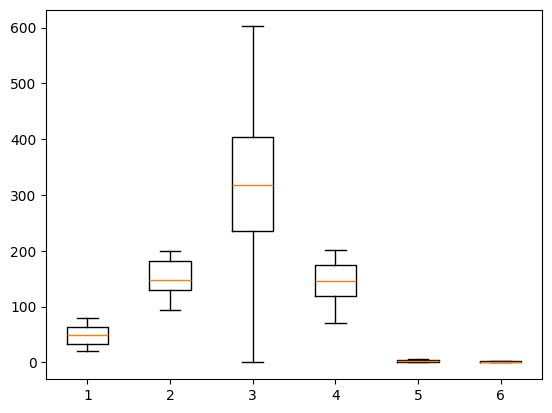

In [ ]:
# Visualize for outliers
plt.boxplot(df_drop)
plt.show()

<Axes: xlabel='age', ylabel='Density'>

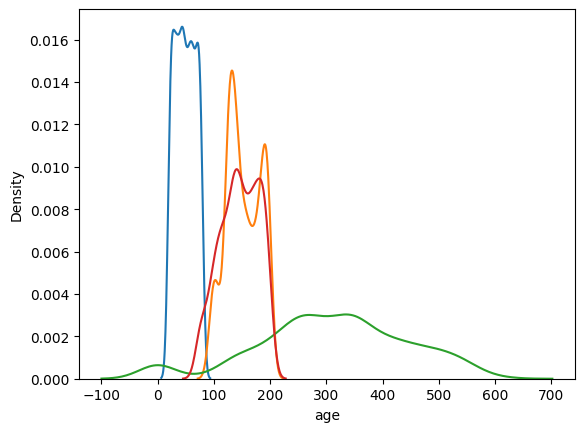

In [ ]:
# Visualize data if it follows normal distribution

sns.kdeplot(df_drop['age'])
sns.kdeplot(df_drop['restingBP'])
sns.kdeplot(df_drop['serumcholestrol'])
sns.kdeplot(df_drop['maxheartrate'])

<Axes: xlabel='oldpeak', ylabel='Density'>

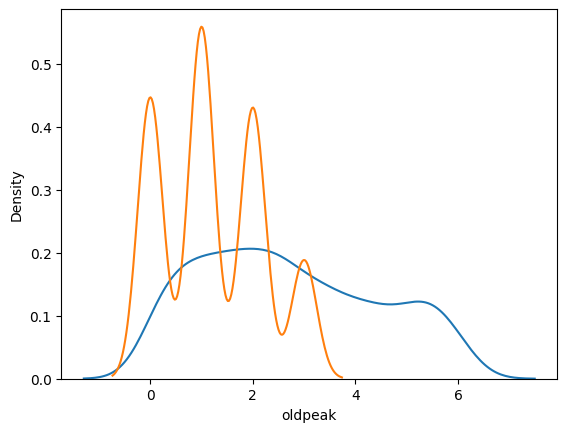

In [ ]:
# Visualize data if it follows normal distribution

sns.kdeplot(df_drop['oldpeak'])
sns.kdeplot(df_drop['noofmajorvessels'])

In [ ]:
# Scale the data using MinMaxScaler

scaler = MinMaxScaler()

features = scaler.fit(df_drop)
features = features.transform(df_drop)

# Convert to pandas Dataframe
scaled_df = pd.DataFrame(features, columns=df_drop.columns)
scaled_df.head()

,age,restingBP,serumcholestrol,maxheartrate,oldpeak,noofmajorvessels
0,0.550000,0.726415,0.000000,0.580153,0.854839,1.000000
1,0.333333,0.000000,0.380399,0.335878,0.596774,0.333333
2,0.483333,0.367925,0.235880,1.000000,0.806452,0.000000
3,0.383333,0.415094,0.490033,0.625954,0.516129,0.666667
4,0.183333,0.990566,0.000000,0.496183,0.854839,0.666667


<Axes: xlabel='age', ylabel='Density'>

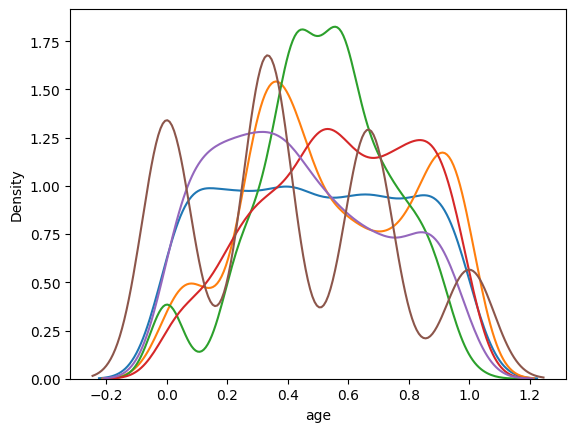

In [ ]:
sns.kdeplot(scaled_df['age'])
sns.kdeplot(scaled_df['restingBP'])
sns.kdeplot(scaled_df['serumcholestrol'])
sns.kdeplot(scaled_df['maxheartrate'])
sns.kdeplot(scaled_df['oldpeak'])
sns.kdeplot(scaled_df['noofmajorvessels'])

In [ ]:
#removing low information features, if any
selection = VarianceThreshold(threshold=0.001)
selection_ = selection.fit_transform(scaled_df)
print("Original shape:", scaled_df.shape)
print("Selection shape:", selection_.shape)

Original shape: (1000, 6)
Selection shape: (1000, 6)


With original data space

1 467.8337141746473
2 377.71103926253704
3 341.5509607871309
4 309.9293836430989
5 291.0719623503851
6 272.0667403160263
7 251.1786858252051
8 237.77300187497366
9 227.10627300467874
10 217.31471786261056


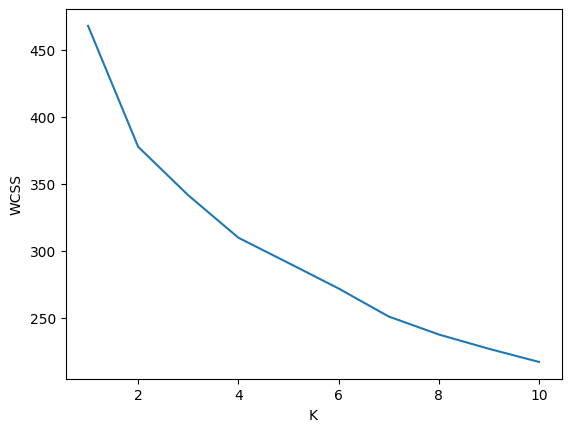

In [ ]:
# KMeans for vanilla autoencoder

wcss = []
ks = []
X = scaled_df
for i in range(1, 11):
  ks.append(i)
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

for i in range(len(ks)):
  print(ks[i], wcss[i])

# Create the line plot
plt.plot(ks, wcss)

# Add labels and a title
plt.xlabel('K')
plt.ylabel('WCSS')

# Display the plot
plt.show()

K_selected_elbow = 3 # By inspection

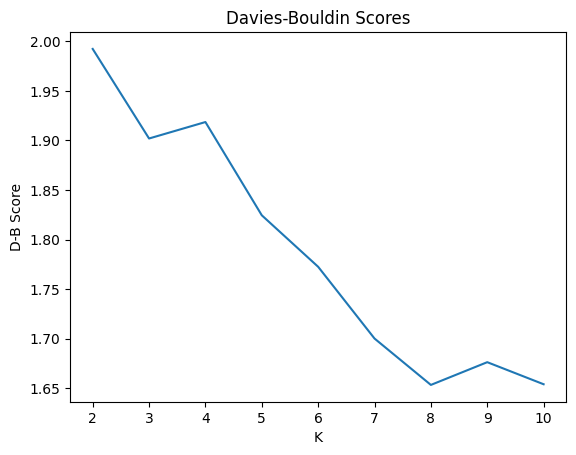

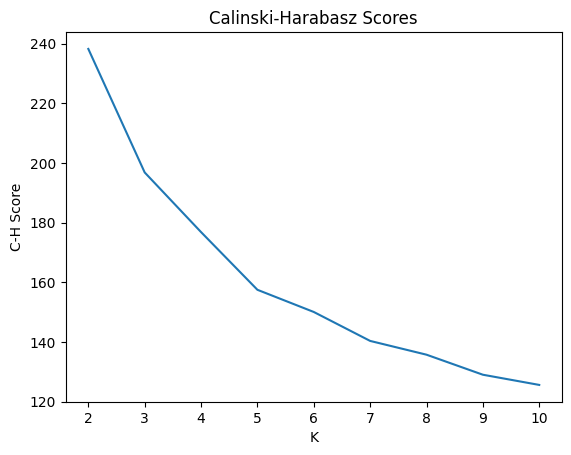

In [ ]:
# Davies-Bouldin

from sklearn.metrics import davies_bouldin_score

davies = {}
for k in range (2,11):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(scaled_df)
  davies[k] = davies_bouldin_score(scaled_df, kmeans.labels_)

plt.plot(list(davies.keys()),list(davies.values()))
plt.title('Davies-Bouldin Scores')
plt.xlabel('K')
plt.ylabel('D-B Score')
plt.show()

# Calinski-Harabasz Index

from sklearn.metrics import calinski_harabasz_score

calinski = {}
for k in range (2,11):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(scaled_df)
  calinski[k] = calinski_harabasz_score(scaled_df, kmeans.labels_)

plt.plot(list(calinski.keys()),list(calinski.values()))
plt.title('Calinski-Harabasz Scores')
plt.xlabel('K')
plt.ylabel('C-H Score')
plt.show()

In [ ]:
K_selected = 8

kmeans = KMeans(n_clusters = K_selected, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(scaled_df)

print(kmeans.cluster_centers_)
print(kmeans.labels_)

k_means_silhouette = silhouette_score(scaled_df, kmeans.labels_)
print('=' * 80)
print(f'The Silhouette Score for K-means is: {k_means_silhouette}')

[[0.36918465 0.68657527 0.58164631 0.60310835 0.19598515 0.76258993]
 [0.79160401 0.85629167 0.55996303 0.54663376 0.41341256 0.35839599]
 [0.31234568 0.33431167 0.45556786 0.8190557  0.38769415 0.16296296]
 [0.29002525 0.68010292 0.56148696 0.65880176 0.7664956  0.63131313]
 [0.81946309 0.2981512  0.48212892 0.49772017 0.35040052 0.21252796]
 [0.22142857 0.88299436 0.53671744 0.58937246 0.34457478 0.17748918]
 [0.73958333 0.48132862 0.52213109 0.60138359 0.60047043 0.84722222]
 [0.28896882 0.30168318 0.45412175 0.26750508 0.46472499 0.1558753 ]]
[6 7 2 3 3 3 4 2 4 1 1 1 2 7 1 3 3 1 1 7 5 1 7 6 3 4 5 3 6 0 2 5 6 2 0 4 1
 3 7 7 3 6 0 6 5 4 2 5 7 7 4 3 3 5 0 1 2 6 1 7 6 1 4 7 4 0 1 6 6 7 1 1 0 7
 1 3 1 4 2 3 2 3 2 6 7 1 0 2 2 5 4 3 0 0 0 5 2 3 4 3 5 2 4 5 5 4 6 7 3 5 5
 4 2 7 4 4 3 4 6 3 3 6 7 4 4 4 6 4 1 4 1 7 6 0 0 2 0 3 7 0 2 1 0 4 5 3 6 2
 7 7 0 0 3 2 1 4 4 6 7 1 4 6 2 0 3 4 7 0 1 0 2 4 1 7 1 3 3 6 4 4 4 1 6 5 7
 1 2 0 0 6 1 1 5 2 4 7 0 1 2 1 1 6 3 1 0 2 3 0 0 0 5 3 0 4 3 1 0 4 7 2 5

With Vanilla Autoencoder

In [ ]:
# Converting to PyTorch tensor, use 'target' as y value

numpy_df = scaled_df.to_numpy()
X_tensor = torch.FloatTensor(numpy_df)

# Converting string labels to numerical labels
label_encoder = LabelEncoder()
Y_numerical = label_encoder.fit_transform(df['target'])

In [ ]:
# Vanilla autoencoder

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder: Compresses data
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, latent_dim) # Bottleneck
        )

        # Decoder: Reconstructs data
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 4),
            nn.ReLU(),
            nn.Linear(4, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return latent,reconstruction

# Setup
unsup_dataset = torch.FloatTensor(scaled_df.values)
unsup_loader = torch.utils.data.DataLoader(unsup_dataset, batch_size=64, shuffle=True)

ae_model = Autoencoder(input_dim=scaled_df.shape[1], latent_dim=3).to(device)
ae_criterion = nn.MSELoss() # Mean Squared Error for reconstruction
ae_optimizer = optim.Adam(ae_model.parameters(), lr=0.001)

Epoch [1/50], Loss: 0.1858
Epoch [2/50], Loss: 0.1694
Epoch [3/50], Loss: 0.1578
Epoch [4/50], Loss: 0.1208
Epoch [5/50], Loss: 0.1028
Epoch [6/50], Loss: 0.1113
Epoch [7/50], Loss: 0.0981
Epoch [8/50], Loss: 0.0901
Epoch [9/50], Loss: 0.1020
Epoch [10/50], Loss: 0.0766
Epoch [11/50], Loss: 0.0747
Epoch [12/50], Loss: 0.0791
Epoch [13/50], Loss: 0.0715
Epoch [14/50], Loss: 0.0628
Epoch [15/50], Loss: 0.0691
Epoch [16/50], Loss: 0.0645
Epoch [17/50], Loss: 0.0657
Epoch [18/50], Loss: 0.0705
Epoch [19/50], Loss: 0.0620
Epoch [20/50], Loss: 0.0600
Epoch [21/50], Loss: 0.0694
Epoch [22/50], Loss: 0.0561
Epoch [23/50], Loss: 0.0615
Epoch [24/50], Loss: 0.0665
Epoch [25/50], Loss: 0.0590
Epoch [26/50], Loss: 0.0612
Epoch [27/50], Loss: 0.0613
Epoch [28/50], Loss: 0.0611
Epoch [29/50], Loss: 0.0594
Epoch [30/50], Loss: 0.0573
Epoch [31/50], Loss: 0.0640
Epoch [32/50], Loss: 0.0596
Epoch [33/50], Loss: 0.0571
Epoch [34/50], Loss: 0.0532
Epoch [35/50], Loss: 0.0537
Epoch [36/50], Loss: 0.0606
E

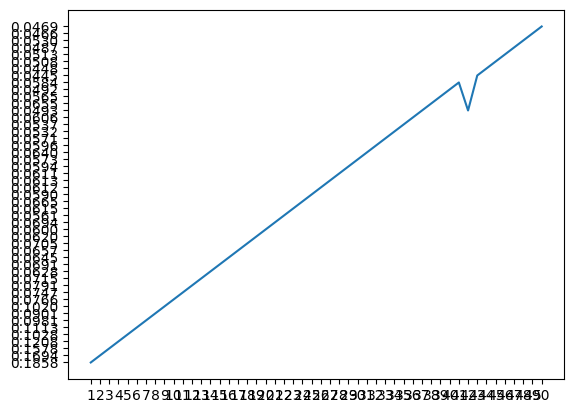

In [ ]:
input_dim = scaled_df.shape[1]  # Number of input features
latent_dim = 3  # Desired number of output dimensions
model = Autoencoder(input_dim, latent_dim)
epochs = []
losses = []

# Training the autoencoder
num_epochs = 50
for epoch in range(num_epochs):
  for (ix,batch) in enumerate(unsup_loader):
    ae_model.train()
    inputs,outputs = ae_model(batch)
    loss = ae_criterion(outputs, batch)

    # Backward pass and optimization
    ae_optimizer.zero_grad()
    loss.backward()
    ae_optimizer.step()
  epochs.append(f'{epoch+1}')
  losses.append(f'{loss.item():.4f}')
  print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Turn last encoded dataset into numpy array, then turn into dataframe
numpy_array = inputs.detach().numpy()
df_reduced = pd.DataFrame(numpy_array)
print(df_reduced.head())

# Plot loss per
plt.plot(epochs,losses)

1 11.16231632232666
2 5.895030498504639
3 3.825502634048462
4 2.892780303955078
5 2.2376344203948975
6 1.776031732559204
7 1.485640048980713
8 1.2032424211502075
9 1.0141148567199707
10 0.861173152923584


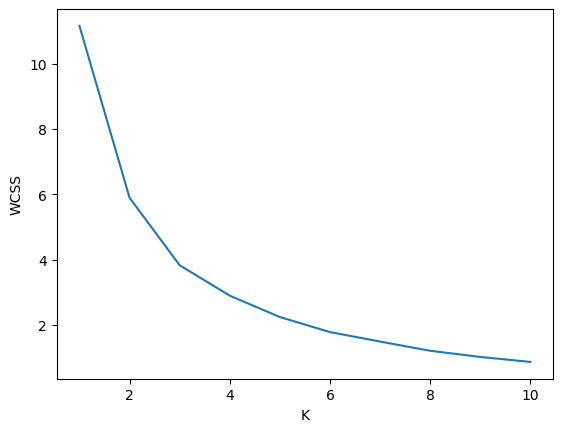

In [ ]:
# KMeans

wcss = []
ks = []

for i in range(1, 11):
  ks.append(i)
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(df_reduced)
  wcss.append(kmeans.inertia_)

for i in range(len(ks)):
  print(ks[i], wcss[i])

# Create the line plot
plt.plot(ks, wcss)

# Add labels and a title
plt.xlabel('K')
plt.ylabel('WCSS')

# Display the plot
plt.show()

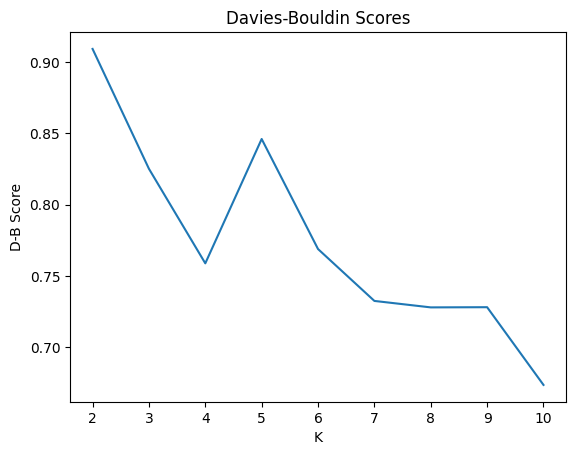

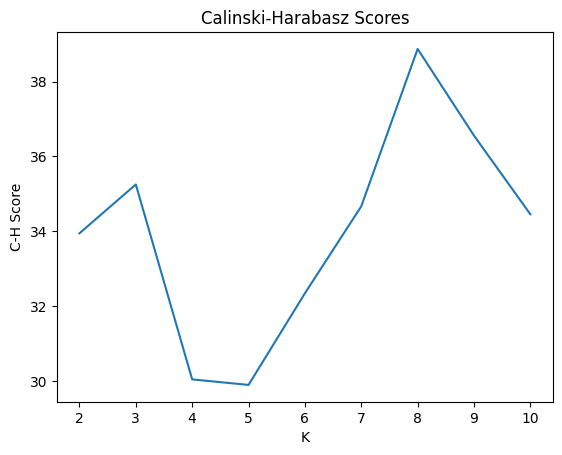

In [ ]:
# Davies-Bouldin

from sklearn.metrics import davies_bouldin_score

davies = {}
for k in range (2,11):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(df_reduced)
  davies[k] = davies_bouldin_score(df_reduced, kmeans.labels_)

plt.plot(list(davies.keys()),list(davies.values()))
plt.title('Davies-Bouldin Scores')
plt.xlabel('K')
plt.ylabel('D-B Score')
plt.show()

# Calinski-Harabasz Index

from sklearn.metrics import calinski_harabasz_score

calinski = {}
for k in range (2,11):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(df_reduced)
  calinski[k] = calinski_harabasz_score(df_reduced, kmeans.labels_)

plt.plot(list(calinski.keys()),list(calinski.values()))
plt.title('Calinski-Harabasz Scores')
plt.xlabel('K')
plt.ylabel('C-H Score')
plt.show()

In [ ]:
K_selected = 7

kmeans = KMeans(n_clusters = K_selected, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(df_reduced)

print(kmeans.cluster_centers_)
print(kmeans.labels_)

k_means_silhouette = silhouette_score(df_reduced, kmeans.labels_)
print('=' * 80)
print(f'The Silhouette Score for K-means is: {k_means_silhouette}')

[[-1.3365066   0.53132415  0.44933033]
 [-1.4686561  -0.46703923  0.48206073]
 [-0.9600364  -0.07275717  0.22432798]
 [-1.699512    0.00238597  0.6044625 ]
 [-0.9224165   0.8814755   0.24137345]
 [-1.6720275   0.57134235  0.62048674]
 [-1.0563649   0.30668724  0.2657982 ]]
[0 0 1 6 6 1 2 5 6 1 2 6 2 5 0 1 6 6 2 2 1 4 3 2 1 2 0 0 3 6 6 6 5 0 3 4 0
 6 1 3]
The Silhouette Score for K-means is: 0.37334808707237244


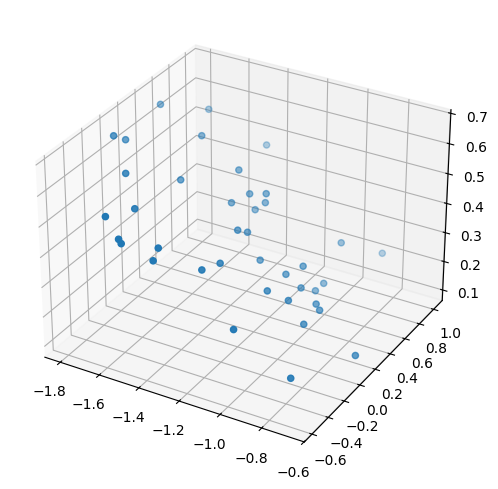

In [ ]:
# Visualize results

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot
ax.scatter3D(df_reduced[0], df_reduced[1], df_reduced[2])

With modified autoencoder

In [ ]:
# Modified autoencoder

class ModAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(ModAutoencoder, self).__init__()

        # Encoder: Compresses data
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, latent_dim) # Bottleneck
        )

        # Decoder: Reconstructs data
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 4),
            nn.Softmax(dim=1),
            nn.Linear(4, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return latent,reconstruction

# Setup
mae_model = ModAutoencoder(input_dim=scaled_df.shape[1], latent_dim=3).to(device)
mae_criterion = nn.CrossEntropyLoss()
mae_optimizer = optim.Adam(mae_model.parameters(), lr=0.001)

Epoch [1/50], Loss: 5.7966
Epoch [2/50], Loss: 5.5964
Epoch [3/50], Loss: 5.3080
Epoch [4/50], Loss: 5.3612
Epoch [5/50], Loss: 5.1804
Epoch [6/50], Loss: 5.6226
Epoch [7/50], Loss: 5.2885
Epoch [8/50], Loss: 5.4404
Epoch [9/50], Loss: 5.2811
Epoch [10/50], Loss: 5.0734
Epoch [11/50], Loss: 5.2812
Epoch [12/50], Loss: 5.3616
Epoch [13/50], Loss: 5.1671
Epoch [14/50], Loss: 5.4225
Epoch [15/50], Loss: 5.1747
Epoch [16/50], Loss: 5.1293
Epoch [17/50], Loss: 5.4893
Epoch [18/50], Loss: 5.4805
Epoch [19/50], Loss: 5.2029
Epoch [20/50], Loss: 4.8798
Epoch [21/50], Loss: 5.2089
Epoch [22/50], Loss: 5.2226
Epoch [23/50], Loss: 5.3338
Epoch [24/50], Loss: 4.9041
Epoch [25/50], Loss: 5.4750
Epoch [26/50], Loss: 5.3303
Epoch [27/50], Loss: 5.4533
Epoch [28/50], Loss: 5.2231
Epoch [29/50], Loss: 5.2361
Epoch [30/50], Loss: 5.4150
Epoch [31/50], Loss: 5.7633
Epoch [32/50], Loss: 5.1595
Epoch [33/50], Loss: 5.2032
Epoch [34/50], Loss: 5.3920
Epoch [35/50], Loss: 5.8771
Epoch [36/50], Loss: 4.7034
E

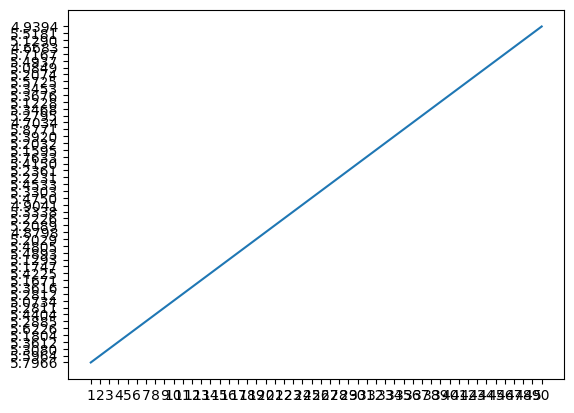

In [ ]:
input_dim = scaled_df.shape[1]  # Number of input features
latent_dim = 3  # Desired number of output dimensions
epochs = []
losses = []

# Training the autoencoder
num_epochs = 50
for epoch in range(num_epochs):
  for (ix,batch) in enumerate(unsup_loader):
    mae_model.train()
    inputs,outputs = mae_model(batch)
    loss = mae_criterion(outputs, batch)

    # Backward pass and optimization
    mae_optimizer.zero_grad()
    loss.backward()
    mae_optimizer.step()
  epochs.append(f'{epoch+1}')
  losses.append(f'{loss.item():.4f}')
  print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Turn last encoded dataset into numpy array, then turn into dataframe
numpy_array = inputs.detach().numpy()
df_mod = pd.DataFrame(numpy_array)
print(df_mod.head())

# Plot loss per
plt.plot(epochs,losses)

1 15.681473731994629
2 3.8165273666381836
3 1.6482008695602417
4 0.8323089480400085
5 0.5597808957099915
6 0.41540274024009705
7 0.26497137546539307
8 0.18521010875701904
9 0.1740637868642807
10 0.14240312576293945


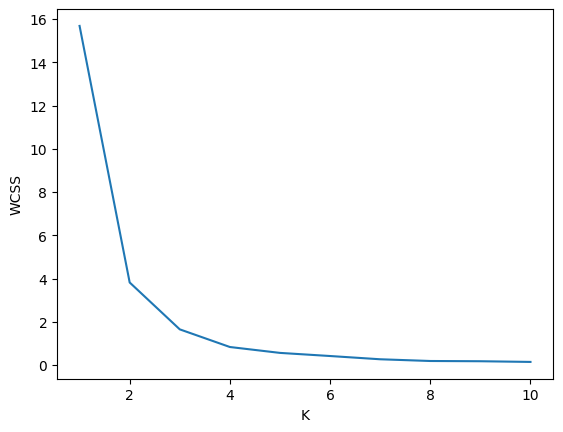

In [ ]:
# KMeans

wcss = []
ks = []

for i in range(1, 11):
  ks.append(i)
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(df_mod)
  wcss.append(kmeans.inertia_)

for i in range(len(ks)):
  print(ks[i], wcss[i])

# Create the line plot
plt.plot(ks, wcss)

# Add labels and a title
plt.xlabel('K')
plt.ylabel('WCSS')

# Display the plot
plt.show()

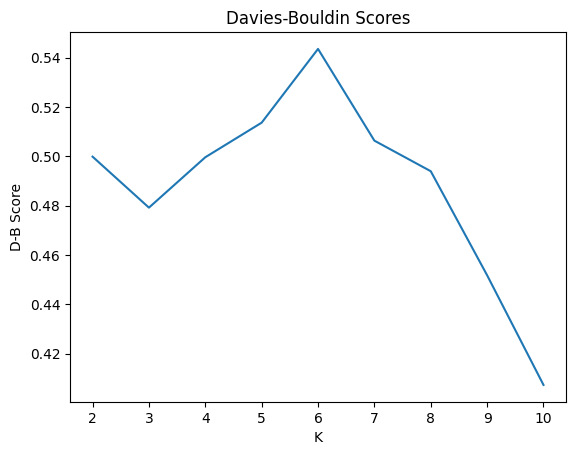

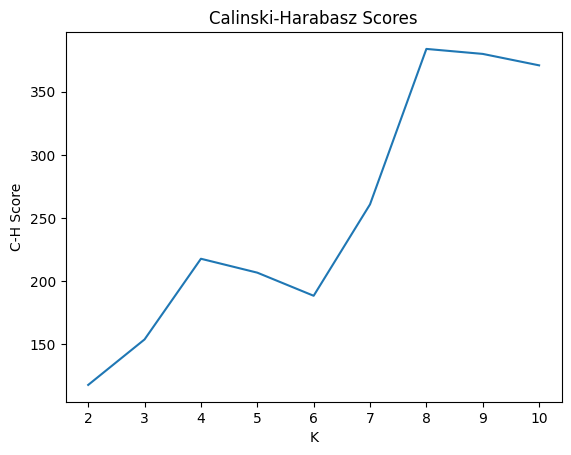

In [ ]:
# Davies-Bouldin

from sklearn.metrics import davies_bouldin_score

davies = {}
for k in range (2,11):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(df_mod)
  davies[k] = davies_bouldin_score(df_mod, kmeans.labels_)

plt.plot(list(davies.keys()),list(davies.values()))
plt.title('Davies-Bouldin Scores')
plt.xlabel('K')
plt.ylabel('D-B Score')
plt.show()

# Calinski-Harabasz Index

from sklearn.metrics import calinski_harabasz_score

calinski = {}
for k in range (2,11):
  kmeans = KMeans(n_clusters=k, random_state=1).fit(df_mod)
  calinski[k] = calinski_harabasz_score(df_mod, kmeans.labels_)

plt.plot(list(calinski.keys()),list(calinski.values()))
plt.title('Calinski-Harabasz Scores')
plt.xlabel('K')
plt.ylabel('C-H Score')
plt.show()

In [ ]:
K_selected = 3

kmeans = KMeans(n_clusters = K_selected, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(df_mod)

print(kmeans.cluster_centers_)
print(kmeans.labels_)

k_means_silhouette = silhouette_score(df_mod, kmeans.labels_)
print('=' * 80)
print(f'The Silhouette Score for K-means is: {k_means_silhouette}')

[[ 0.76881623  1.2834926  -0.12150388]
 [-0.1390289   0.13308173 -0.13986874]
 [ 0.37044105  0.76242644 -0.13664246]]
[1 2 2 0 0 2 0 2 2 2 1 2 0 2 0 1 2 2 0 0 1 0 2 0 1 0 1 0 0 1 0 1 1 0 2 1 2
 0 1 0]
The Silhouette Score for K-means is: 0.5772531628608704


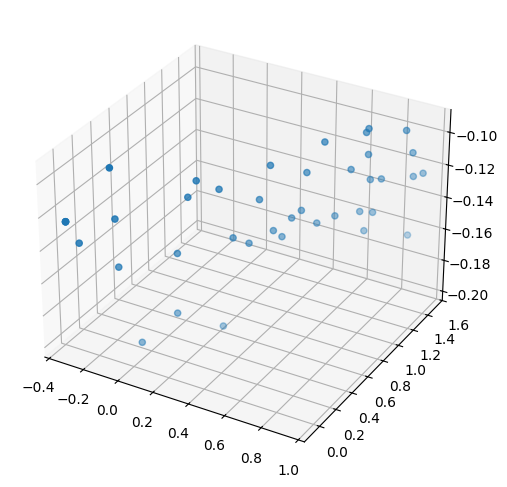

In [ ]:
# Visualize results

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Create scatter plot
ax.scatter3D(df_mod[0], df_mod[1], df_mod[2])